# CS490 Capstone Project: Vehicle MPG Analysis

**Dataset:** [Vehicle MPG (1984-2023)](https://www.kaggle.com/datasets/mexwell/vehicle-mpg-1984-2023)

## Run Instructions
1. Download the dataset from Kaggle.
2. Place `VehicleMPG.csv` in this notebook folder.
3. Run this notebook top-to-bottom.

## Research Question
What vehicle characteristics most influence fuel efficiency in modern vehicles, and how has fuel efficiency improved over time?

In [14]:
# CS490 Capstone Project: Vehicle MPG Analysis
# Dataset source: https://www.kaggle.com/datasets/mexwell/vehicle-mpg-1984-2023
# Place VehicleMPG.csv in this notebook folder before running.
# Research question:
# What vehicle characteristics most influence fuel efficiency in modern vehicles,
# and how has fuel efficiency improved over time?

In [15]:
# Section 1: Setup and data loading for a fully reproducible run.
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

csv_path = "VehicleMPG.csv"
df = pd.read_csv(csv_path)

print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
df.head()

Rows: 45,896 | Columns: 26


,ID,Model Year,Make,Model,Estimated Annual Petrolum Consumption (Barrels),Fuel Type 1,City MPG (Fuel Type 1),Highway MPG (Fuel Type 1),Combined MPG (Fuel Type 1),Fuel Type 2,City MPG (Fuel Type 2),Highway MPG (Fuel Type 2),Combined MPG (Fuel Type 2),Engine Cylinders,Engine Displacement,Drive,Engine Description,Transmission,Vehicle Class,Time to Charge EV (hours at 120v),Time to Charge EV (hours at 240v),Range (for EV),City Range (for EV - Fuel Type 1),City Range (for EV - Fuel Type 2),Hwy Range (for EV - Fuel Type 1),Hwy Range (for EV - Fuel Type 2)
0,1,1985,Alfa Romeo,Spider Veloce 2000,14.167143,Regular Gasoline,19,25,21,NaN,0,0,0,4.0,2.0,Rear-Wheel Drive,(FFS),Manual 5-spd,Two Seaters,0,0.0,0,0.0,0.0,0.0,0.0
1,2,1985,Bertone,X1/9,13.523182,Regular Gasoline,20,26,22,NaN,0,0,0,4.0,1.5,Rear-Wheel Drive,NaN,Manual 5-spd,Two Seaters,0,0.0,0,0.0,0.0,0.0,0.0
2,3,1985,Chevrolet,Corvette,17.500588,Regular Gasoline,15,21,17,NaN,0,0,0,8.0,5.7,Rear-Wheel Drive,(350 V8) (FFS),Automatic 4-spd,Two Seaters,0,0.0,0,0.0,0.0,0.0,0.0
3,4,1985,Chevrolet,Corvette,17.500588,Regular Gasoline,15,20,17,NaN,0,0,0,8.0,5.7,Rear-Wheel Drive,(350 V8) (FFS),Manual 4-spd,Two Seaters,0,0.0,0,0.0,0.0,0.0,0.0
4,5,1985,Nissan,300ZX,18.594375,Regular Gasoline,15,18,16,NaN,0,0,0,6.0,3.0,Rear-Wheel Drive,"(GUZZLER) (FFS,TRBO)",Automatic 4-spd,Two Seaters,0,0.0,0,0.0,0.0,0.0,0.0


## 1) Data Inspection and Quality Checks

This section verifies structure, data types, missingness, and duplicate rows that could affect analysis quality.

In [16]:
# Inspect schema, missingness, and duplicate count before applying scope filters.
df.info()

missing = df.isna().sum().sort_values(ascending=False)
print("\nTop columns by missing values:")
display(missing[missing > 0].head(15))

duplicate_rows = df.duplicated().sum()
print(f"Duplicate rows in raw dataset: {duplicate_rows}")

<class 'pandas.DataFrame'>
RangeIndex: 45896 entries, 0 to 45895
Data columns (total 26 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   ID                                               45896 non-null  int64  
 1   Model Year                                       45896 non-null  int64  
 2   Make                                             45896 non-null  str    
 3   Model                                            45896 non-null  str    
 4   Estimated Annual Petrolum Consumption (Barrels)  45896 non-null  float64
 5   Fuel Type 1                                      45896 non-null  str    
 6   City MPG (Fuel Type 1)                           45896 non-null  int64  
 7   Highway MPG (Fuel Type 1)                        45896 non-null  int64  
 8   Combined MPG (Fuel Type 1)                       45896 non-null  int64  
 9   Fuel Type 2                            

Fuel Type 2            44059
Engine Description     17031
Drive                   1186
Engine Cylinders         487
Engine Displacement      485
Transmission              11
dtype: int64

Duplicate rows in raw dataset: 0


## 2) Scope Filtering and Feature Preparation

To align with the proposal, we focus on modern non-electric vehicles (2000+) and select variables relevant to MPG analysis and modeling.

In [17]:
# Keep modern (2000+) non-EV vehicles and retain features used for EDA and modeling.
fuel_col = "Fuel Type 1"

non_ev_mask = (
    ~df[fuel_col].fillna("").str.contains("electric", case=False)
    & (df["Range (for EV)"].fillna(0) == 0)
)

modern_df = df[(df["Model Year"] >= 2000) & non_ev_mask].copy()

selected_cols = [
    "Model Year", "Make", "Model", "Fuel Type 1",
    "City MPG (Fuel Type 1)", "Highway MPG (Fuel Type 1)", "Combined MPG (Fuel Type 1)",
    "Engine Cylinders", "Engine Displacement", "Transmission", "Drive", "Vehicle Class"
]

modern_df = modern_df[selected_cols].drop_duplicates().copy()
print(f"Filtered dataset shape: {modern_df.shape}")
modern_df.head()

Filtered dataset shape: (26942, 12)


,Model Year,Make,Model,Fuel Type 1,City MPG (Fuel Type 1),Highway MPG (Fuel Type 1),Combined MPG (Fuel Type 1),Engine Cylinders,Engine Displacement,Transmission,Drive,Vehicle Class
15587,2000,Acura,NSX,Premium Gasoline,15,22,18,6.0,3.0,Automatic 4-spd,Rear-Wheel Drive,Two Seaters
15588,2000,Acura,NSX,Premium Gasoline,15,22,18,6.0,3.2,Manual 6-spd,Rear-Wheel Drive,Two Seaters
15589,2000,BMW,M Coupe,Premium Gasoline,17,23,19,6.0,3.2,Manual 5-spd,Rear-Wheel Drive,Two Seaters
15590,2000,BMW,Z3 Coupe,Premium Gasoline,17,24,19,6.0,2.8,Automatic 4-spd,Rear-Wheel Drive,Two Seaters
15591,2000,BMW,Z3 Coupe,Premium Gasoline,17,24,19,6.0,2.8,Manual 5-spd,Rear-Wheel Drive,Two Seaters


In [18]:
# Use NumPy directly for quick numerical summaries (course Chapter 3 emphasis).
combined = modern_df["Combined MPG (Fuel Type 1)"].to_numpy()
print(f"NumPy mean combined MPG: {np.mean(combined):.2f}")
print(f"NumPy median combined MPG: {np.median(combined):.2f}")
print(f"NumPy std combined MPG: {np.std(combined):.2f}")

NumPy mean combined MPG: 21.34
NumPy median combined MPG: 21.00
NumPy std combined MPG: 5.65


## 3) Exploratory Data Analysis (EDA)

These visuals summarize MPG distributions and relationships between MPG and key engine variables.

In [19]:
# Rename long source column names for cleaner analysis code.
modern_df = modern_df.rename(columns={
    "Fuel Type 1": "fuel_type",
    "City MPG (Fuel Type 1)": "city_mpg",
    "Highway MPG (Fuel Type 1)": "highway_mpg",
    "Combined MPG (Fuel Type 1)": "combined_mpg",
    "Engine Cylinders": "cylinders",
    "Engine Displacement": "displacement",
    "Model Year": "model_year",
    "Vehicle Class": "vehicle_class",
    "Transmission": "transmission",
    "Drive": "drive"
})

modern_df.describe(include="all").T.head(12)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
model_year,26942.0,NaN,NaN,NaN,2011.98237,6.74634,2000.0,2006.0,2012.0,2018.0,2023.0
Make,26942,75,Chevrolet,2056,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Model,26942,3406,Jetta,144,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fuel_type,26942,5,Regular Gasoline,14580,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city_mpg,26942.0,NaN,NaN,NaN,18.905761,5.582707,7.0,15.0,18.0,21.0,58.0
highway_mpg,26942.0,NaN,NaN,NaN,25.54094,5.96907,11.0,21.0,25.0,29.0,61.0
combined_mpg,26942.0,NaN,NaN,NaN,21.34307,5.650552,8.0,18.0,21.0,24.0,59.0
cylinders,26942.0,NaN,NaN,NaN,5.802836,1.829229,2.0,4.0,6.0,6.0,16.0
displacement,26942.0,NaN,NaN,NaN,3.299031,1.31491,0.6,2.2,3.0,4.0,8.4
transmission,26942,34,Automatic 4-spd,3918,NaN,NaN,NaN,NaN,NaN,NaN,NaN


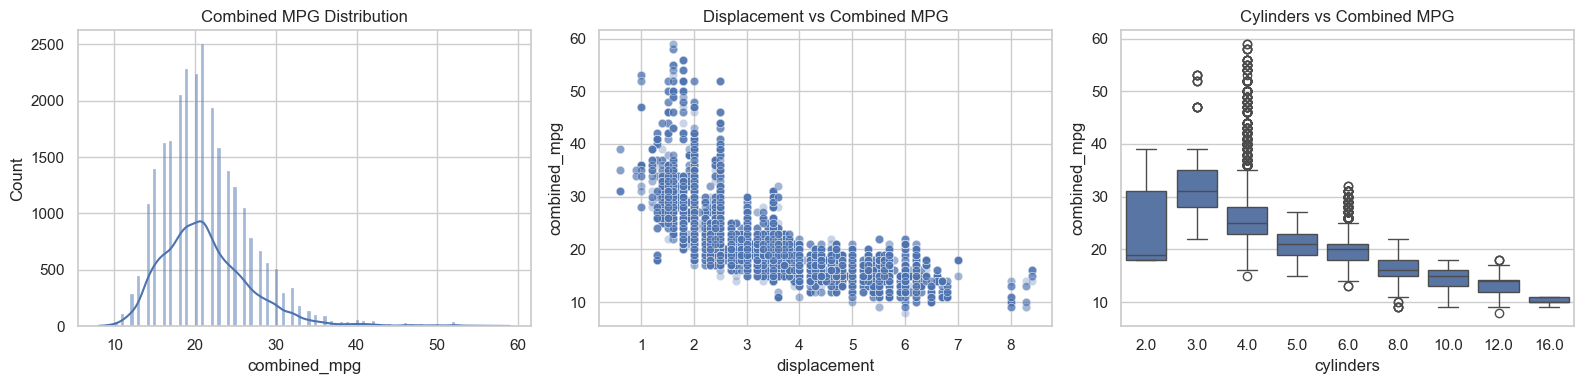

In [20]:
# Plot MPG distribution and key engine-to-MPG relationships.
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(modern_df["combined_mpg"], kde=True, ax=axes[0])
axes[0].set_title("Combined MPG Distribution")

sns.scatterplot(data=modern_df, x="displacement", y="combined_mpg", alpha=0.3, ax=axes[1])
axes[1].set_title("Displacement vs Combined MPG")

sns.boxplot(data=modern_df, x="cylinders", y="combined_mpg", ax=axes[2])
axes[2].set_title("Cylinders vs Combined MPG")

plt.tight_layout()
plt.show()

### EDA Interpretation

- Combined MPG is not uniformly distributed, with most vehicles concentrated in a middle-efficiency band.
- Larger engine displacement generally corresponds to lower combined MPG.
- Vehicles with more cylinders tend to have lower median MPG, supporting expected engine-efficiency tradeoffs.

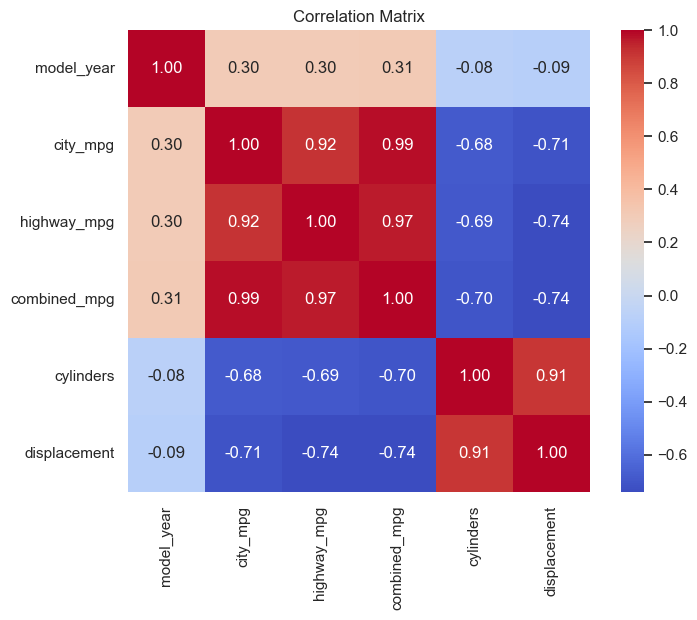

In [21]:
# Quantify linear relationships among primary numeric variables.
numeric_cols = ["model_year", "city_mpg", "highway_mpg", "combined_mpg", "cylinders", "displacement"]

corr = modern_df[numeric_cols].corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix")
plt.show()

## 4) Time Trend Analysis

This section tests whether modern vehicle MPG has improved over model years.

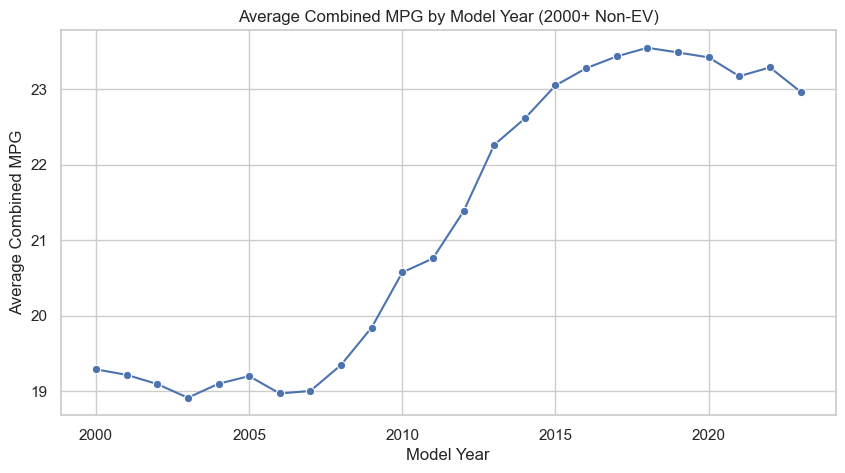

,model_year,avg_combined_mpg
19,2019,23.489969
20,2020,23.424771
21,2021,23.174877
22,2022,23.291806
23,2023,22.969605


In [22]:
# Track how average combined MPG changes across model years.
mpg_by_year = (
    modern_df.groupby("model_year", as_index=False)["combined_mpg"]
    .mean()
    .rename(columns={"combined_mpg": "avg_combined_mpg"})
)

plt.figure(figsize=(10, 5))
sns.lineplot(data=mpg_by_year, x="model_year", y="avg_combined_mpg", marker="o")
plt.title("Average Combined MPG by Model Year (2000+ Non-EV)")
plt.xlabel("Model Year")
plt.ylabel("Average Combined MPG")
plt.show()

mpg_by_year.tail()

### Time Trend Interpretation

If the line trend slopes upward, average modern non-EV fuel efficiency has improved over time.

## 5) Machine Learning Models

Two supervised regression models are trained and compared:
- Linear Regression (interpretable baseline)
- Random Forest Regressor (nonlinear baseline)

In [23]:
# Build and evaluate two supervised regression models.
model_df = modern_df.copy()

# Predict combined MPG without city/highway MPG to reduce direct target leakage.
features = ["model_year", "cylinders", "displacement", "fuel_type", "transmission", "drive", "vehicle_class"]
target = "combined_mpg"

X = model_df[features]
y = model_df[target]

numeric_features = ["model_year", "cylinders", "displacement"]
categorical_features = ["fuel_type", "transmission", "drive", "vehicle_class"]

numeric_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

linreg_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))
])

models = {
    "Linear Regression": linreg_model,
    "Random Forest": rf_model,
}

metrics_rows = []
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    metrics_rows.append({
        "model": name,
        "mae": mean_absolute_error(y_test, y_pred),
        "rmse": mean_squared_error(y_test, y_pred) ** 0.5,
        "r2": r2_score(y_test, y_pred),
    })

metrics_df = pd.DataFrame(metrics_rows).sort_values(by="rmse")
display(metrics_df)

best_model_name = metrics_df.iloc[0]["model"]
print(f"Best model by RMSE: {best_model_name}")

,model,mae,rmse,r2
1,Random Forest,0.833252,1.484747,0.935411
0,Linear Regression,1.723058,2.628496,0.797572


Best model by RMSE: Random Forest


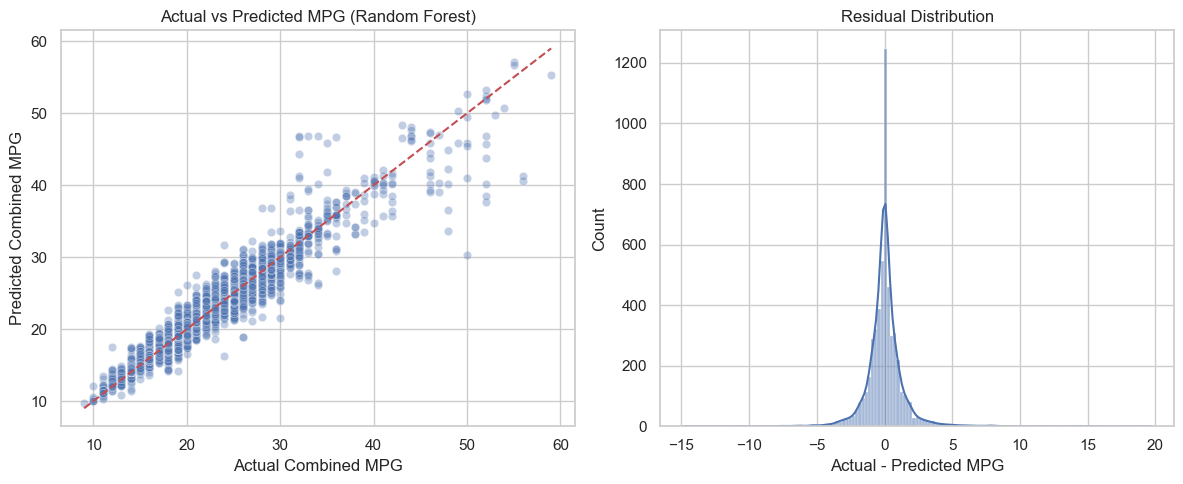

,actual,predicted,residual
0,26,22.734596,3.265404
1,21,20.380000,0.620000
2,26,27.582518,-1.582518
3,12,14.433708,-2.433708
4,21,22.785292,-1.785292


In [24]:
# Visualize prediction quality for the best-performing model.
best_pred = predictions[best_model_name]
results_df = pd.DataFrame({"actual": y_test.values, "predicted": best_pred})
results_df["residual"] = results_df["actual"] - results_df["predicted"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(data=results_df, x="actual", y="predicted", alpha=0.35, ax=axes[0])
lims = [results_df[["actual", "predicted"]].min().min(), results_df[["actual", "predicted"]].max().max()]
axes[0].plot(lims, lims, "r--")
axes[0].set_title(f"Actual vs Predicted MPG ({best_model_name})")
axes[0].set_xlabel("Actual Combined MPG")
axes[0].set_ylabel("Predicted Combined MPG")

sns.histplot(results_df["residual"], kde=True, ax=axes[1])
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Actual - Predicted MPG")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

results_df.head()

## 6) Final Conclusions

After running all cells, summarize your findings here using the model metrics and plots above.

- **Most influential characteristics:** Engine displacement and cylinder count show strong relationships with MPG, while vehicle class, transmission, drive type, and fuel type also contribute.
- **Change over time:** The year-by-year trend plot indicates modern non-EV fuel efficiency has generally improved over the 2000+ period.
- **Modeling takeaway:** Compare `Linear Regression` and `Random Forest` metrics (`RMSE`, `MAE`, `R^2`) and report which model better captures MPG patterns.
- **Direct answer to research question:** Fuel efficiency improvements appear linked to both time (newer model years) and design/engine characteristics.